##  EfficientNet-B0 Model

In [ ]:
from torchvision import models
import torch.nn as nn

efficientnet_model = models.efficientnet_b0(weights=None)

# 1-channel grayscale input
efficientnet_model.features[0][0] = nn.Conv2d(
    1,
    32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

# 2-class output
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features,
    2
)

efficientnet_model = efficientnet_model.to(device)

print("EfficientNet-B0 model created successfully.")

EfficientNet-B0 model created successfully.


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    efficientnet_model.parameters(),
    lr=0.0001
)

num_epochs = 1

efficientnet_train_losses = []
efficientnet_valid_losses = []
efficientnet_train_accuracies = []
efficientnet_valid_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        efficientnet_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate(
        efficientnet_model,
        valid_loader,
        criterion,
        device
    )

    efficientnet_train_losses.append(train_loss)
    efficientnet_valid_losses.append(valid_loss)
    efficientnet_train_accuracies.append(train_acc)
    efficientnet_valid_accuracies.append(valid_acc)

    print(f"\nEfficientNet-B0 Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Accuracy: {valid_acc:.2f}%")


EfficientNet-B0 Epoch [1/1]
Train Loss: 0.6306
Train Accuracy: 63.35%
Valid Loss: 0.5587
Valid Accuracy: 73.36%


# EfficientNet-B0 Training and Validation Analysis

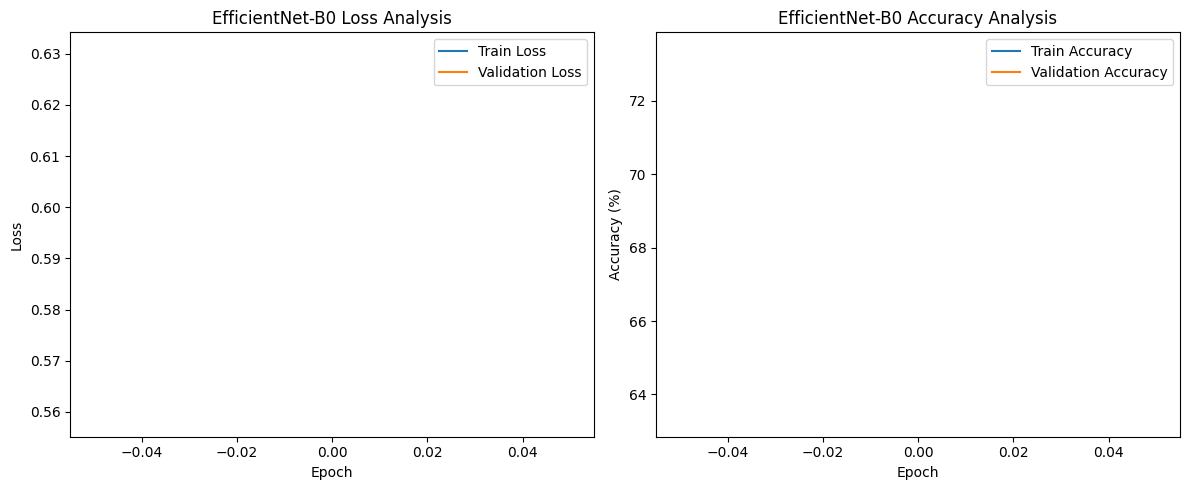

In [ ]:
plt.figure(figsize=(12,5))

# Loss Graph
plt.subplot(1,2,1)

plt.plot(efficientnet_train_losses, label='Train Loss')
plt.plot(efficientnet_valid_losses, label='Validation Loss')

plt.title('EfficientNet-B0 Loss Analysis')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

# Accuracy Graph
plt.subplot(1,2,2)

plt.plot(efficientnet_train_accuracies, label='Train Accuracy')
plt.plot(efficientnet_valid_accuracies, label='Validation Accuracy')

plt.title('EfficientNet-B0 Accuracy Analysis')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.legend()

plt.tight_layout()

plt.savefig('../outputs/efficientnet_training_analysis.png')

plt.show()

# EfficientNet Test Evaluation

In [ ]:
efficientnet_model.eval()

efficientnet_all_labels = []
efficientnet_all_preds = []
efficientnet_all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        efficientnet_all_probs.extend(probs[:, 1].cpu().numpy())
        efficientnet_all_preds.extend(preds.cpu().numpy())
        efficientnet_all_labels.extend(labels.cpu().numpy())

efficientnet_all_probs = np.array(efficientnet_all_probs)
efficientnet_all_preds = np.array(efficientnet_all_preds)
efficientnet_all_labels = np.array(efficientnet_all_labels)

print("Evaluation completed.")

Evaluation completed.


# EfficientNet Confusion Matrix

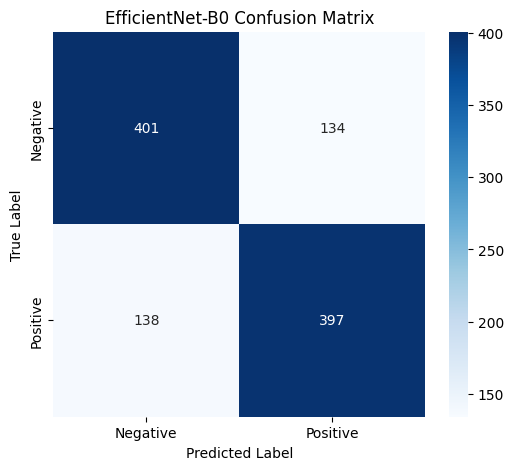

TN: 401
FP: 134
FN: 138
TP: 397


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    efficientnet_all_labels,
    efficientnet_all_preds
)

tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('EfficientNet-B0 Confusion Matrix')

plt.show()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

# EfficientNet Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(
    efficientnet_all_labels,
    efficientnet_all_preds
)

precision = precision_score(
    efficientnet_all_labels,
    efficientnet_all_preds
)

recall = recall_score(
    efficientnet_all_labels,
    efficientnet_all_preds
)

specificity = tn / (tn + fp)

f1 = f1_score(
    efficientnet_all_labels,
    efficientnet_all_preds
)

auc = roc_auc_score(
    efficientnet_all_labels,
    efficientnet_all_probs
)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"ROC-AUC    : {auc:.4f}")

Accuracy   : 0.7458
Precision  : 0.7476
Recall     : 0.7421
Specificity: 0.7495
F1-Score   : 0.7448
ROC-AUC    : 0.8177


# EfficientNet ROC Curve

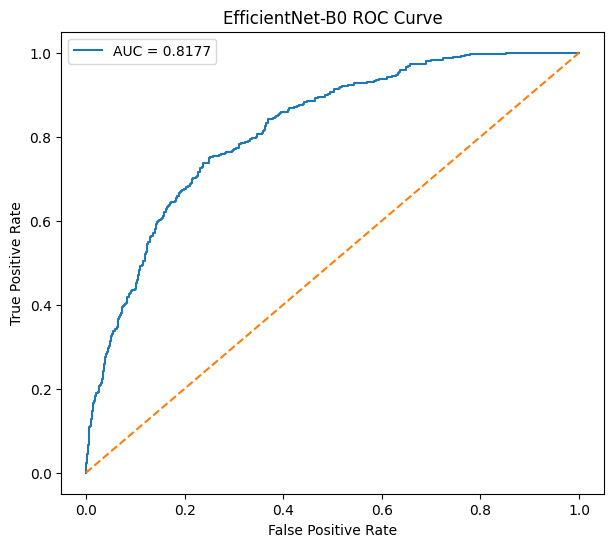

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    efficientnet_all_labels,
    efficientnet_all_probs
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNet-B0 ROC Curve")

plt.legend()

plt.show()

### EfficientNet-B0 Evaluation Summary

EfficientNet-B0 achieved moderate classification performance after one training epoch. Although the model trained successfully using transfer learning and CLAHE preprocessing, its overall validation accuracy remained lower than the ResNet18 baseline model.

However, EfficientNet-B0 demonstrated efficient learning behavior while using a lightweight architecture, making it computationally efficient for medical image analysis tasks.